In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install    mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 46.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


Loading All 3 Pipeline Models and Preprocessing Stats...
Scanning and Categorizing EDF files to create a balanced subset...
Found files count -> FNSZ: 154 | GNSZ: 24 | CPSZ: 18
Total files selected for evaluation: 108

Running Memory-Optimized Pipeline...
Evaluating Pipeline: 100%|██████████| 108/108 [17:00<00:00,  9.45s/it]

Pipeline Processing Complete!

STAGE 2 PERFORMANCE
              precision    recall  f1-score   support

  Background       0.30      0.74      0.42      3500
     Seizure       0.97      0.85      0.91     40253

    accuracy                           0.84     43753
   macro avg       0.64      0.79      0.67     43753
weighted avg       0.92      0.84      0.87     43753


STAGE 3 PERFORMANCE
              precision    recall  f1-score   support

        fnsz       0.58      0.45      0.51      3943
        gnsz       0.99      0.77      0.87     31766
        cpsz       0.36      0.56      0.44      4544
 Missed/Bckg       0.00      0.00      0.00         0

 

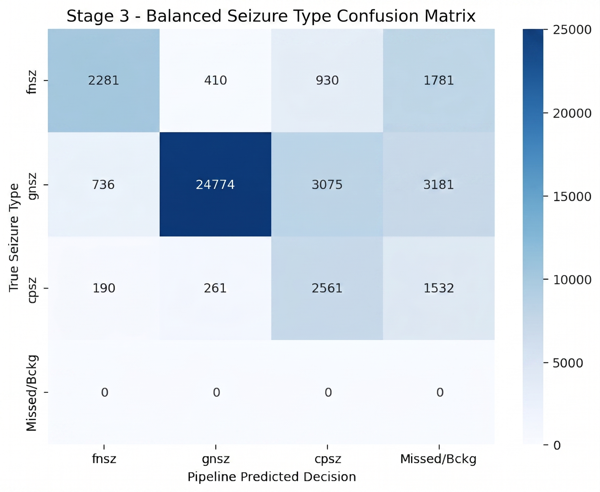

In [ ]:
import os
import glob
import random
import pickle
import numpy as np
import pandas as pd
import mne
import scipy.signal
import scipy.stats
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc
import warnings

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

TEST_DATA_DIR = '/content/drive/MyDrive/gp_dataset/seizure_v2_split/test'
TARGET_TEST_FILES = 200

STAGE1_MODEL_PATH = '/content/drive/MyDrive/gp_dataset/abnormal_v3.0.1/Models/TCN+XGBoost/best_tcn.keras'
STAGE1_MEAN_PATH  = '/content/drive/MyDrive/gp_dataset/abnormal_v3.0.1/Models/TCN+XGBoost/global_mean.npy'
STAGE1_STD_PATH   = '/content/drive/MyDrive/gp_dataset/abnormal_v3.0.1/Models/TCN+XGBoost/global_std.npy'
STAGE1_THRESHOLD  = 0.5
STAGE1_CHANNELS   = ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']
STAGE1_SFREQ      = 100.0
STAGE1_WINDOW     = 60

STAGE2_MODEL_PATH  = '/content/drive/MyDrive/gp_dataset/model_results_v4_fusion/Final_Champion_Gatekeeper_v4.h5'
STAGE2_THRESHOLD   = 0.2445
CHANNELS_ORDER_S2  = [
    'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4',
    'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6',
    'A1', 'A2', 'FZ', 'CZ'
]
STAGE2_SFREQ       = 128.0
STAGE2_WINDOW_SEC  = 10.0
STAGE2_POINTS      = int(STAGE2_WINDOW_SEC * STAGE2_SFREQ)
STAGE2_OVERLAP     = int(STAGE2_POINTS * 0.5)
MAX_BKG_WINDOWS    = 100

TARGET_CLASSES_S2  = ['fnsz', 'gnsz', 'cpsz', 'bckg']

STAGE3_MODEL_PATH  = '/content/drive/MyDrive/gp_dataset/model_results_3classes_v1_split/final_Seizure_Type_Classifier_v1_LSTM.h5'
TARGET_CLASSES_S3  = ['fnsz', 'gnsz', 'cpsz']
LABEL_MAP_S3       = {lbl: idx for idx, lbl in enumerate(TARGET_CLASSES_S3)}


def apply_bandpass_s1(data, fs):
    nyq = 0.5 * fs
    b, a = scipy.signal.butter(5, [0.5/nyq, 40.0/nyq], btype='band')
    return scipy.signal.filtfilt(b, a, data, axis=1)


def extract_advanced_features_batch_s2(batch_data, sfreq=128.0):
    B, C, T_pts = batch_data.shape
    num_features = 15

    mean_val = np.mean(batch_data, axis=-1)
    std_val  = np.std(batch_data, axis=-1)
    skew_val = scipy.stats.skew(batch_data, axis=-1)
    kurt_val = scipy.stats.kurtosis(batch_data, axis=-1)

    freqs, psd = scipy.signal.welch(batch_data, sfreq, nperseg=256, axis=-1)
    bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30)}
    powers = []
    for low, high in bands.values():
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        powers.append(np.trapz(psd[:, :, idx_band], freqs[idx_band], axis=-1))

    powers = np.array(powers)
    total_power = np.sum(powers, axis=0) + 1e-8
    rel_powers = powers / total_power
    delta_theta_ratio = powers[0] / (powers[1] + 1e-8)

    d1 = np.diff(batch_data, axis=-1)
    d2 = np.diff(d1, axis=-1)
    var_zero = np.var(batch_data, axis=-1)
    var_d1   = np.var(d1, axis=-1)
    var_d2   = np.var(d2, axis=-1)

    act = var_zero
    mob = np.sqrt(var_d1 / np.where(var_zero == 0, 1e-8, var_zero))
    comp = np.sqrt(var_d2 / np.where(var_d1 == 0, 1e-8, var_d1)) / np.where(mob == 0, 1e-8, mob)

    psd_norm = psd / (np.sum(psd, axis=-1, keepdims=True) + 1e-8)
    entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-8), axis=-1)

    mean_corr = np.zeros((B, C))
    analytic_signal = scipy.signal.hilbert(batch_data, axis=-1)
    Z = analytic_signal / (np.abs(analytic_signal) + 1e-8)

    for b in range(B):
        corr_matrix = np.corrcoef(batch_data[b])
        mean_corr[b] = np.mean(np.abs(corr_matrix), axis=1)

    plv_matrix = np.abs(Z @ np.swapaxes(Z.conj(), 1, 2)) / T_pts
    mean_plv = (np.sum(plv_matrix, axis=-1) - 1.0) / (C - 1)

    features_per_channel = np.stack((
        mean_val, std_val, skew_val, kurt_val,
        rel_powers[0], rel_powers[1], rel_powers[2], rel_powers[3],
        delta_theta_ratio, act, mob, comp, entropy, mean_corr, mean_plv
    ), axis=-1)

    spatial_map = np.zeros((B, 5, 5, num_features))
    mapping = {
        (0,1): 0,  (0,2): 18, (0,3): 1,
        (1,0): 10, (1,1): 2,  (1,3): 3,  (1,4): 11,
        (2,0): 12, (2,1): 4,  (2,2): 19, (2,3): 5,  (2,4): 13,
        (3,0): 14, (3,1): 6,  (3,3): 7,  (3,4): 15,
        (4,0): 16, (4,1): 8,  (4,3): 9,  (4,4): 17
    }
    for (row, col), ch_idx in mapping.items():
        spatial_map[:, row, col, :] = features_per_channel[:, ch_idx, :]

    return spatial_map

def extract_advanced_features_vectorized_s2(data_arr, batch_size=32):
    total = data_arr.shape[0]
    out = []
    for i in range(0, total, batch_size):
        out.append(extract_advanced_features_batch_s2(data_arr[i:i+batch_size], sfreq=STAGE2_SFREQ))
    return np.concatenate(out, axis=0)


def extract_frequency_maps_batch_s3(batch_data, sfreq=128.0):
    B, C, T_pts = batch_data.shape
    num_bands = 5
    freqs, psd = scipy.signal.welch(batch_data, sfreq, nperseg=256, axis=-1)

    bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 40)}
    powers = []
    for low, high in bands.values():
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        powers.append(np.trapz(psd[:, :, idx_band], freqs[idx_band], axis=-1))

    psd_features = np.stack(powers, axis=-1)
    spatial_map = np.zeros((B, 5, 5, num_bands))

    mapping = {
        (0,1): 0,  (0,2): 18, (0,3): 1,
        (1,0): 10, (1,1): 2,  (1,3): 3,  (1,4): 11,
        (2,0): 12, (2,1): 4,  (2,2): 19, (2,3): 5,  (2,4): 13,
        (3,0): 14, (3,1): 6,  (3,3): 7,  (3,4): 15,
        (4,0): 16, (4,1): 8,  (4,3): 9,  (4,4): 17
    }
    for (row, col), ch_idx in mapping.items():
        spatial_map[:, row, col, :] = psd_features[:, ch_idx, :]

    mean_val = np.mean(spatial_map, axis=(1,2,3), keepdims=True)
    std_val = np.std(spatial_map, axis=(1,2,3), keepdims=True)
    spatial_map = (spatial_map - mean_val) / (std_val + 1e-8)
    return spatial_map

def extract_frequency_maps_vectorized_s3(data_arr, batch_size=32):
    total = data_arr.shape[0]
    out = []
    for i in range(0, total, batch_size):
        out.append(extract_frequency_maps_batch_s3(data_arr[i:i+batch_size], sfreq=STAGE2_SFREQ))
    return np.concatenate(out, axis=0)


if __name__ == "__main__":
    print("Loading All 3 Pipeline Models and Preprocessing Stats...")
    stage1_model = tf.keras.models.load_model(STAGE1_MODEL_PATH)
    g_mean_s1 = np.load(STAGE1_MEAN_PATH).reshape(-1, 1)
    g_std_s1  = np.load(STAGE1_STD_PATH).reshape(-1, 1)
    stage2_model = tf.keras.models.load_model(STAGE2_MODEL_PATH)
    stage3_model = tf.keras.models.load_model(STAGE3_MODEL_PATH)

    print(f"Scanning and Categorizing EDF files to create a balanced subset...")
    all_csv_files = []
    if os.path.exists(TEST_DATA_DIR):
        for root, dirs, files in os.walk(TEST_DATA_DIR):
            for file in files:
                if file.lower().endswith('.csv') or file.lower().endswith('.csv_bi'):
                    all_csv_files.append(os.path.join(root, file))

    if len(all_csv_files) == 0:
        print(f"Error: No CSV files found.")
        exit()

    fnsz_files, gnsz_files, cpsz_files = [], [], []
    for csv_p in all_csv_files:
        try:
            df_tmp = pd.read_csv(csv_p, skiprows=6, header=None)
            labels_set = set(df_tmp[3].astype(str).str.lower().str.strip().tolist())
            if 'gnsz' in labels_set: gnsz_files.append(csv_p)
            elif 'cpsz' in labels_set: cpsz_files.append(csv_p)
            elif any(x in labels_set for x in ['fnsz', 'spsz', 'tnsz', 'seiz']): fnsz_files.append(csv_p)
        except: continue

    print(f"Found files count -> FNSZ: {len(fnsz_files)} | GNSZ: {len(gnsz_files)} | CPSZ: {len(cpsz_files)}")
    files_per_class = TARGET_TEST_FILES // 3

    selected_fnsz = random.sample(fnsz_files, min(files_per_class, len(fnsz_files)))
    selected_gnsz = random.sample(gnsz_files, min(files_per_class, len(gnsz_files)))
    selected_cpsz = random.sample(cpsz_files, min(files_per_class, len(cpsz_files)))

    test_csvs = selected_fnsz + selected_gnsz + selected_cpsz
    random.shuffle(test_csvs)
    print(f"Total files selected for evaluation: {len(test_csvs)}")

    y_true_s1, y_pred_s1 = [], []
    y_true_s2, y_pred_s2 = [], []
    y_true_s3, y_pred_s3 = [], []

    print(f"\nRunning Memory-Optimized Pipeline...")
    for csv_path in tqdm(test_csvs, desc="Evaluating Pipeline"):
        raw = None
        raw_s1 = None
        try:
            base_path = csv_path
            if base_path.lower().endswith('.csv_bi'): base_path = base_path[:-7]
            elif base_path.lower().endswith('.csv'): base_path = base_path[:-4]
            edf_path = base_path + '.edf'
            if not os.path.exists(edf_path): continue

            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            new_names = {ch: ch.upper().replace('EEG ', '').replace('-REF', '').replace('-LE', '') for ch in raw.ch_names}
            raw.rename_channels(new_names)

            actual_s2_picks = []
            channels_exist = True
            for target in CHANNELS_ORDER_S2:
                found_ch = [ch for ch in raw.ch_names if ch == target]
                if found_ch: actual_s2_picks.append(raw.ch_names.index(found_ch[0]))
                else: channels_exist = False; break

            if not all(ch in raw.ch_names for ch in STAGE1_CHANNELS) or not channels_exist: continue

            df_ann = pd.read_csv(csv_path, skiprows=6, header=None)
            y_true_s1.append(1)

            raw_s1 = raw.copy().pick_channels(STAGE1_CHANNELS, ordered=True)
            raw_s1.load_data(verbose=False)
            if raw_s1.info['sfreq'] != STAGE1_SFREQ: raw_s1.resample(STAGE1_SFREQ, verbose=False)
            data_s1 = raw_s1.get_data()
            start_s1 = int(1 * 60 * STAGE1_SFREQ)

            stage1_pred = 0
            if data_s1.shape[1] > start_s1 + (60 * STAGE1_SFREQ):
                data_s1 = data_s1[:, start_s1:]
                data_s1 = apply_bandpass_s1(data_s1, STAGE1_SFREQ)
                data_s1 = np.clip((data_s1 - g_mean_s1) / (g_std_s1 + 1e-8), -5, 5)
                n_wins = data_s1.shape[1] // 6000
                if n_wins > 0:
                    windows_s1 = np.array([data_s1[:, i*6000:(i+1)*6000] for i in range(n_wins)], dtype=np.float32)
                    probs_s1 = stage1_model.predict(windows_s1, verbose=0).flatten()
                    if np.max(probs_s1) >= STAGE1_THRESHOLD: stage1_pred = 1

            y_pred_s1.append(stage1_pred)
            del data_s1, raw_s1
            gc.collect()

            orig_sfreq = raw.info['sfreq']
            file_windows_raw_list = []
            file_y_true_label = []
            bckg_count = 0
            raw.load_data(verbose=False)

            for _, r in df_ann.iterrows():
                label = str(r[3]).lower().strip()
                if label not in TARGET_CLASSES_S2: continue
                s_start, s_end = float(r[1]), float(r[2])
                if label == 'bckg' and bckg_count >= MAX_BKG_WINDOWS: continue
                start_idx, end_idx = int(s_start * orig_sfreq), int(s_end * orig_sfreq)

                if label == 'bckg':
                    rem = MAX_BKG_WINDOWS - bckg_count
                    end_idx = min(end_idx, start_idx + int((STAGE2_WINDOW_SEC + (rem - 1) * 5.0 + 5.0) * orig_sfreq))
                if start_idx >= end_idx: continue

                data_s2 = raw.get_data(picks=actual_s2_picks, start=start_idx, stop=end_idx)
                if data_s2.shape[1] == 0: continue
                if orig_sfreq != STAGE2_SFREQ:
                    data_s2 = mne.filter.resample(data_s2, up=STAGE2_SFREQ, down=orig_sfreq, verbose=False)
                data_s2 = mne.filter.notch_filter(data_s2, STAGE2_SFREQ, freqs=60.0, verbose=False)
                data_s2 = mne.filter.filter_data(data_s2, STAGE2_SFREQ, l_freq=0.5, h_freq=40.0, verbose=False)

                median_val = np.median(data_s2, axis=1, keepdims=True)
                iqr_val = np.percentile(data_s2, 75, axis=1, keepdims=True) - np.percentile(data_s2, 25, axis=1, keepdims=True)
                data_s2 = np.clip((data_s2 - median_val) / (iqr_val + 1e-8), -5.0, 5.0)

                for win_start in range(0, data_s2.shape[1] - STAGE2_POINTS + 1, STAGE2_OVERLAP):
                    if label == 'bckg':
                        if bckg_count >= MAX_BKG_WINDOWS: break
                        bckg_count += 1
                    file_windows_raw_list.append(data_s2[:, win_start:win_start + STAGE2_POINTS])
                    file_y_true_label.append('fnsz' if label in ['spsz', 'tnsz', 'absz', 'mycl', 'seiz'] else label)

            if len(file_windows_raw_list) == 0: continue
            raw_windows_arr = np.stack(file_windows_raw_list)

            if stage1_pred == 1:
                X_raw_input_s2 = np.swapaxes(raw_windows_arr, 1, 2).astype(np.float32)
                X_eng_input_s2 = extract_advanced_features_vectorized_s2(raw_windows_arr, batch_size=32).astype(np.float32)
                probs_s2 = stage2_model.predict([X_raw_input_s2, X_eng_input_s2], verbose=0).flatten()
                preds_s2 = (probs_s2 > STAGE2_THRESHOLD).astype(int)

                s3_indices = []
                for idx, pred_is_seizure in enumerate(preds_s2):
                    true_label = file_y_true_label[idx]
                    y_true_s2.append(0 if true_label == 'bckg' else 1)
                    y_pred_s2.append(pred_is_seizure)
                    if true_label in LABEL_MAP_S3:
                        y_true_s3.append(LABEL_MAP_S3[true_label])
                        if pred_is_seizure == 1: s3_indices.append(idx)
                        else: y_pred_s3.append(3)

                if len(s3_indices) > 0:
                    s3_wins = raw_windows_arr[s3_indices]
                    X_raw_s3 = np.swapaxes(s3_wins, 1, 2).astype(np.float32)
                    X_eng_s3 = extract_frequency_maps_vectorized_s3(s3_wins, batch_size=32).astype(np.float32)
                    probs_s3 = stage3_model.predict([X_raw_s3, X_eng_s3], verbose=0)
                    preds_s3 = np.argmax(probs_s3, axis=1)
                    for p_s3 in preds_s3: y_pred_s3.append(p_s3)
            else:
                for idx, true_label in enumerate(file_y_true_label):
                    y_true_s2.append(0 if true_label == 'bckg' else 1)
                    y_pred_s2.append(0)
                    if true_label in LABEL_MAP_S3:
                        y_true_s3.append(LABEL_MAP_S3[true_label])
                        y_pred_s3.append(3)
        except Exception as e:
            print(f"Error {os.path.basename(csv_path)}: {e}")
            continue
        finally:
            if raw is not None: raw.close()
            try: del raw, data_s2, file_windows_raw_list, raw_windows_arr, X_raw_input_s2, X_eng_input_s2
            except: pass
            gc.collect()
            tf.keras.backend.clear_session()

    print(f"\nPipeline Processing Complete!")
    print("\n" + "="*60 + "\nSTAGE 2 PERFORMANCE\n" + "="*60)
    print(classification_report(y_true_s2, y_pred_s2, target_names=['Background', 'Seizure']))

    if len(y_true_s3) > 0:
        print("\n" + "="*60 + "\nSTAGE 3 PERFORMANCE\n" + "="*60)
        y_true_s3, y_pred_s3 = np.array(y_true_s3), np.array(y_pred_s3)
        extended_classes = TARGET_CLASSES_S3 + ['Missed/Bckg']
        print(classification_report(y_true_s3, y_pred_s3, labels=[0, 1, 2, 3], target_names=extended_classes))

        cm_s3 = confusion_matrix(y_true_s3, y_pred_s3, labels=[0, 1, 2, 3])
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_s3, annot=True, fmt='d', cmap='blue', xticklabels=extended_classes, yticklabels=TARGET_CLASSES_S3)
        plt.title('Stage 3 - Balanced Seizure Type Confusion Matrix')
        plt.xlabel('Pipeline Predicted Decision')
        plt.ylabel('True Seizure Type')
        plt.show()